# Run the protected-dissent experiment

Run this notebook from top to bottom with **Shift+Enter**. Progress appears below the collection cells; responses are saved to disk as requests finish. Tables and figures appear after collection. The default is a small **offline software demo**, not research evidence.

## Anaconda setup (once)
In **Anaconda Prompt**, run:
```bat
cd C:\Users\MingZeTang\Documents\GitHub\aamas27
conda create -n dissent-research python=3.11 -y
conda activate dissent-research
python -m pip install -r requirements-analysis.txt
python -m ipykernel install --user --name dissent-conda --display-name "Dissent Research (Anaconda)"
python -m jupyterlab notebooks/run_experiment.ipynb
```
Select **Dissent Research (Anaconda)** as the notebook kernel. Alternatively, open JupyterLab through Anaconda Navigator in that environment. This notebook uses your selected kernel's Python, not the repository's `.venv`.

Keep credentials in the repository's `.env`; do not paste or display keys in cells. No installation or paid requests happen merely by opening this notebook.

In [3]:
from pathlib import Path
import os, sys, json
from IPython.display import display, Markdown

# If Jupyter starts elsewhere, replace None with the absolute repository path.
PROJECT_ROOT = None
if PROJECT_ROOT is None:
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'dissent' / 'study.py').is_file()), None)
    if ROOT is None:
        raise RuntimeError('Set PROJECT_ROOT to your aamas27 repository path above.')
else:
    ROOT = Path(PROJECT_ROOT).expanduser().resolve()
    if not (ROOT / 'dissent' / 'study.py').is_file():
        raise RuntimeError('PROJECT_ROOT does not contain dissent/study.py')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print('Python:', sys.executable)
print('Repository:', ROOT)
if sys.version_info < (3, 11):
    raise RuntimeError('Use Python 3.11 or newer.')
import pandas as pd
import matplotlib
import nbformat, nbclient
from dissent.common import write_json, read_jsonl
from dissent.tasks import save_dataset
from dissent.environment import load_env
from dissent.study import resolve_plan, execute_study, preflight
from dissent.reporting import write_study_report

Python: c:\Users\MingZeTang\anaconda3\envs\cuda\python.exe
Repository: c:\Users\MingZeTang\Documents\GitHub\aamas27


## Choose the run

- `demo`: six generated questions, mock responses, one repetition; no API charges.
- `preflight`: three new development questions with your configured live model(s), first repetition, all conditions. This checks compatibility, not statistical power.
- `study`: the full settings in `configs/study.json`, currently 600 questions and three repetitions (9,000 independent responses plus deliberation).

For either live mode, deliberately set `ALLOW_LIVE = True`. Check the model/provider and budgets in the config first. Reported-cost thresholds are not hard monetary caps. Preflight limits known reported cost to at most $1.

The study config now starts at 8,192 output tokens. Explicit truncation automatically retries only that call at 16,384 and then 32,768 tokens, subject to attempt/spending limits and provider support. Every attempt is saved. Completed calls in the same run are reused. Older preflight runs used the original policy: keep them as development records and use a new run name with this updated code.

Choose a different `RUN_NAME` for each new experiment. To resume a study, keep its name and settings unchanged. Do not run two notebooks/processes writing to the same directory. Do not tune prompts on evaluation results.

In [4]:
MODE = 'study'                 # 'demo', 'preflight', or 'study'
ALLOW_LIVE = True             # True authorizes paid calls in this notebook
RUN_NAME = 'study-01'  # Change for a new run
RETRY_FAILED = True          # Another bounded retry batch for transient failures

if MODE not in {'demo', 'preflight', 'study'}:
    raise ValueError('Unknown MODE')
if not RUN_NAME or Path(RUN_NAME).name != RUN_NAME or RUN_NAME in {'.', '..'}:
    raise ValueError('RUN_NAME must be a single directory name')
if MODE != 'demo' and not ALLOW_LIVE:
    raise RuntimeError('Review the live settings, then set ALLOW_LIVE=True.')
BASE_CONFIG = ROOT / 'configs/study.json'
RUN_BASE = ROOT / 'runs' / RUN_NAME
RUN_DIR = RUN_BASE / 'run' if MODE == 'preflight' else RUN_BASE
CONFIG = BASE_CONFIG

if MODE == 'demo':
    inputs = ROOT / 'runs' / (RUN_NAME + '-inputs')
    CONFIG = inputs / 'config.json'
    if not CONFIG.exists():
        save_dataset(inputs / 'development', 6, 73491)
        spec = json.loads(BASE_CONFIG.read_text(encoding='utf-8'))
        spec.update(name='notebook-offline-demo',
                    datasets=[{'id': 'development', 'tasks': 'development/tasks.jsonl',
                               'answers': 'development/answers.jsonl'}],
                    models=[{'id': 'fixture', 'backend': 'mock',
                             'model': 'mock-fixture-v1', 'provider': 'offline'}],
                    seeds=[2027], selection='all',
                    limits={'max_requests': 1000, 'max_reported_cost_usd': 1.0})
        spec['statistics']['bootstrap_samples'] = 200
        write_json(CONFIG, spec)
else:
    load_env()

spec, identity, tasks = resolve_plan(CONFIG)
if MODE == 'demo' and any(m['backend'] != 'mock' for m in identity['models']):
    raise RuntimeError('Demo config must contain only mock models.')
panels = len(tasks) * len(identity['models']) * len(identity['seeds'])
display(Markdown('**SYNTHETIC SOFTWARE DEMO**' if MODE == 'demo' else '**PAID LIVE RUN**'))
print('Output directory:', RUN_DIR)
display(pd.DataFrame(identity['models']))
print('Base plan:', len(tasks), 'questions;', panels, 'panels;', 5 * panels, 'initial calls')
print('Limits:', spec['limits'])
if MODE == 'preflight':
    print('Preflight replaces the base dataset with 3 new questions and uses only the first seed.')

**PAID LIVE RUN**

Output directory: c:\Users\MingZeTang\Documents\GitHub\aamas27\runs\study-01


,id,backend,model,provider
0,primary,openrouter,deepseek/deepseek-v4.1-flash,together


Base plan: 600 questions; 1800 panels; 9000 initial calls
Limits: {'max_requests': 90000, 'max_reported_cost_usd': 25.0}


## Collect independent answers (or run the complete preflight)

This cell runs synchronously: wait for it to finish before running the next cell. Each progress line reports a completed/attempted question, not each individual HTTP request. Network timeouts and retry backoff can make a line take time. Request journals are written during collection.

Use **Kernel → Interrupt** to stop collection; completed calls remain saved. For a study/demo, rerun this cell to resume. Set `RETRY_FAILED=True` only when another bounded batch of transient/ambiguous failures is intended. Permanent configuration errors need correction; changed experimental settings require a new run directory.

Preflight requires a fresh directory. If a preflight is interrupted, follow the resume instructions at the end rather than regenerating its questions.

In [7]:
if MODE == 'preflight':
    if (RUN_DIR / 'research_summary.json').exists():
        print('Using completed preflight. Choose a new RUN_NAME to repeat it.')
    else:
        preflight(BASE_CONFIG, RUN_BASE, live=ALLOW_LIVE)
else:
    execute_study(CONFIG, RUN_DIR, 'independent', live=ALLOW_LIVE,
                  retry_failed=RETRY_FAILED)
print('Saved responses in:', RUN_DIR / 'units')

independent: primary, seed 2029, 325/600
independent: primary, seed 2029, 326/600
independent: primary, seed 2029, 327/600
independent: primary, seed 2029, 328/600
independent: primary, seed 2029, 329/600
independent: primary, seed 2029, 330/600
independent: primary, seed 2029, 331/600
independent: primary, seed 2029, 332/600
independent: primary, seed 2029, 333/600
independent: primary, seed 2029, 334/600
independent: primary, seed 2029, 335/600
independent: primary, seed 2029, 336/600
independent: primary, seed 2029, 337/600
independent: primary, seed 2029, 338/600
independent: primary, seed 2029, 339/600
independent: primary, seed 2029, 340/600
independent: primary, seed 2029, 341/600
independent: primary, seed 2029, 342/600
independent: primary, seed 2029, 343/600
independent: primary, seed 2029, 344/600
independent: primary, seed 2029, 345/600
independent: primary, seed 2029, 346/600
independent: primary, seed 2029, 347/600
independent: primary, seed 2029, 348/600
independent: pri

## Inspect initial disagreement
Classification is automatic. Gold labels are used here for scoring, never for deciding which panels receive deliberation.

In [8]:
write_study_report(RUN_DIR, screen_only=True)
screening = pd.DataFrame(read_jsonl(RUN_DIR / 'screening.jsonl'))
display(screening.groupby(['model_id', 'dataset', 'initial_category'], dropna=False)
        .size().rename('panels').reset_index())
display(screening.head(10))

,model_id,dataset,initial_category,panels
0,primary,bbh,majority_correct_minority_wrong,7
1,primary,bbh,majority_wrong_minority_correct,1
2,primary,bbh,unanimous_correct,892
3,primary,fresh,initial_unavailable,9
4,primary,fresh,majority_correct_minority_wrong,26
5,primary,fresh,unanimous_correct,865


,backend,collection_status,correct_agent_indices_zero_based,correct_answer,dataset,family,initial_answers,initial_available,initial_category,model_id,seed,selected,task_id,vote_counts
0,openrouter,independent_complete,"[0, 1, 2, 3, 4]",D,bbh,bbh_logical_deduction_five_objects,"[D, D, D, D, D]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0004,{'D': 5}
1,openrouter,independent_complete,"[0, 1, 2, 3, 4]",A,bbh,bbh_logical_deduction_five_objects,"[A, A, A, A, A]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0012,{'A': 5}
2,openrouter,independent_complete,"[0, 1, 2, 3, 4]",D,bbh,bbh_logical_deduction_five_objects,"[D, D, D, D, D]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0013,{'D': 5}
3,openrouter,independent_complete,"[0, 1, 2, 3, 4]",A,bbh,bbh_logical_deduction_five_objects,"[A, A, A, A, A]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0014,{'A': 5}
4,openrouter,independent_complete,"[0, 1, 2, 3, 4]",A,bbh,bbh_logical_deduction_five_objects,"[A, A, A, A, A]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0015,{'A': 5}
5,openrouter,independent_complete,"[0, 1, 2, 3, 4]",D,bbh,bbh_logical_deduction_five_objects,"[D, D, D, D, D]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0017,{'D': 5}
6,openrouter,independent_complete,"[0, 1, 2, 3, 4]",D,bbh,bbh_logical_deduction_five_objects,"[D, D, D, D, D]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0024,{'D': 5}
7,openrouter,independent_complete,"[0, 1, 2, 3, 4]",E,bbh,bbh_logical_deduction_five_objects,"[E, E, E, E, E]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0026,{'E': 5}
8,openrouter,independent_complete,"[0, 1, 2, 3, 4]",E,bbh,bbh_logical_deduction_five_objects,"[E, E, E, E, E]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0027,{'E': 5}
9,openrouter,independent_complete,"[0, 1, 2, 3, 4]",A,bbh,bbh_logical_deduction_five_objects,"[A, A, A, A, A]",True,unanimous_correct,primary,2027,False,bbh::bbh/logical_deduction_five_objects/0028,{'A': 5}


## Run deliberation and comparison conditions
This reuses the saved independent responses. Successful requests are cached; transient failures use the existing retry policy. Preflight already completed this step.

In [9]:
if MODE != 'preflight':
    execute_study(CONFIG, RUN_DIR, 'deliberate', live=ALLOW_LIVE,
                  retry_failed=RETRY_FAILED)
else:
    print('Deliberation was included in preflight.')
os.environ['DISSENT_STUDY_DIR'] = str(RUN_DIR)
print('Collection finished. Continue for inline statistical results.')

deliberate: primary, seed 2028, 524/600
deliberate: primary, seed 2028, 525/600
deliberate: primary, seed 2028, 526/600
deliberate: primary, seed 2028, 527/600
deliberate: primary, seed 2028, 528/600
deliberate: primary, seed 2028, 529/600
deliberate: primary, seed 2028, 530/600
deliberate: primary, seed 2028, 531/600
deliberate: primary, seed 2028, 532/600
deliberate: primary, seed 2028, 533/600
deliberate: primary, seed 2028, 534/600
deliberate: primary, seed 2028, 535/600
deliberate: primary, seed 2028, 536/600
deliberate: primary, seed 2028, 537/600
deliberate: primary, seed 2028, 538/600
deliberate: primary, seed 2028, 539/600
deliberate: primary, seed 2028, 540/600
deliberate: primary, seed 2028, 541/600
deliberate: primary, seed 2028, 542/600
deliberate: primary, seed 2028, 543/600
deliberate: primary, seed 2028, 544/600
deliberate: primary, seed 2028, 545/600
deliberate: primary, seed 2028, 546/600
deliberate: primary, seed 2028, 547/600
deliberate: primary, seed 2028, 548/600


## Results, plots, and response audit
The remaining cells reuse the analysis notebook's reporting code. They make no model calls. Demo/preflight samples are too small for research conclusions. Missing results and empty minority strata remain visible; repeated seeds are clustered by question.

In [10]:
from pathlib import Path
import os, sys, json, importlib.metadata, io
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'dissent').is_dir())
sys.path.insert(0, str(ROOT))
RUN_DIR = Path(os.environ.get('DISSENT_STUDY_DIR', str(ROOT / 'runs/study-verified'))).resolve()
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from dissent.reporting import write_study_report
from dissent.common import read_jsonl, write_json

FIGURES = RUN_DIR / 'figures'
EXPORTS = RUN_DIR / 'tables'
FIGURES.mkdir(parents=True, exist_ok=True)
EXPORTS.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_colwidth', 65)
pd.set_option('display.max_rows', 100)
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
def show(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format='png', dpi=120, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))

## Integrity and collection status

The reporting loader checks task and answer-key hashes, task IDs, option labels, panel sizes, and successful call references. A failed collection is not silently converted into an incorrect answer. `success_over_scheduled` deliberately treats unavailable decisions as unsuccessful operational outcomes; complete-case accuracy uses only available decisions.

In [11]:
report = write_study_report(RUN_DIR)
rows = pd.DataFrame(read_jsonl(RUN_DIR / 'analysis_rows.jsonl'))
screen = pd.DataFrame(read_jsonl(RUN_DIR / 'screening.jsonl'))
summary = pd.DataFrame(report['descriptive'])
contrasts = pd.DataFrame(report['contrasts'])
resources = pd.DataFrame(report['resources'])
BANNER = 'SYNTHETIC SOFTWARE TEST' if report['synthetic'] else 'LIVE EXPERIMENT'
display(Markdown(f'**{BANNER}** — collection status: `{report["study_status"]}`'))
display(rows.groupby(['model_id', 'collection_status'], dropna=False)['task_id'].count().rename('protocol_rows').to_frame())
versions = {name: importlib.metadata.version(name) for name in ('numpy', 'pandas', 'matplotlib', 'nbformat', 'nbclient')}
write_json(RUN_DIR / 'analysis_environment.json', {'python':sys.version, 'packages':versions})
print('Questions:', screen.task_id.nunique(), '| model/seed panels:', len(screen), '| protocol rows:', len(rows))

**LIVE EXPERIMENT** — collection status: `complete_with_failures`

protocol_rows
model_id collection_status                
primary  complete                    16101
         deliberate_failed              18
         independent_failed             81

Questions: 600 | model/seed panels: 1800 | protocol rows: 16200


## Initial disagreement and screening

Selection uses initial disagreement, not ground truth. The configured policy stops unanimous panels and deliberates on all disagreeing panels, including majority-correct/minority-wrong cases. The table distinguishes no strict majority from majority-wrong/minority-correct. Repeated panels are not independent questions.

In [12]:
screening_table = screen.groupby(['model_id', 'dataset', 'initial_category'], dropna=False).agg(panels=('task_id','size'), unique_questions=('task_id','nunique')).reset_index()
display(screening_table)
display(screen.groupby(['model_id','dataset'], dropna=False).agg(planned_panels=('task_id','size'), observed_panels=('initial_available','sum'), selected_panels=('selected','sum')))
screening_table.to_csv(EXPORTS / 'screening.csv', index=False)

,model_id,dataset,initial_category,panels,unique_questions
0,primary,bbh,majority_correct_minority_wrong,7,6
1,primary,bbh,majority_wrong_minority_correct,1,1
2,primary,bbh,unanimous_correct,892,299
3,primary,fresh,initial_unavailable,9,9
4,primary,fresh,majority_correct_minority_wrong,26,25
5,primary,fresh,unanimous_correct,865,300


planned_panels  observed_panels selected_panels
model_id dataset                                                 
primary  bbh                 900              900               8
         fresh               900              891              26

## Accuracy, coverage and failure rates

Report public and fresh datasets separately. Overall accuracy reflects the configured unanimity-stop policy if selection is `disagreement`. It is not an estimate of unconditional debate applied to every question. Source/family rows are descriptive; inspect available and scheduled denominators.

,model_id,scope,protocol,available_panels,scheduled_panels,missing_panels,success_over_scheduled,accuracy_complete_cases,coverage_over_scheduled,accuracy_when_resolved
0,primary,all,explicit_dissent,1789,1800,11,0.993889,1.000000,0.993889,1.000000
1,primary,all,extra_round_control,1789,1800,11,0.993889,1.000000,0.993889,1.000000
2,primary,all,independent_review_control,1789,1800,11,0.993889,1.000000,0.993889,1.000000
3,primary,all,independent_revision,1789,1800,11,0.993889,1.000000,0.993889,1.000000
4,primary,all,majority_vote,1791,1800,9,0.994444,0.999442,0.995000,0.999442
5,primary,all,protected_dissent,1789,1800,11,0.993889,1.000000,0.993889,1.000000
6,primary,all,protected_dissent_review,1789,1800,11,0.993889,1.000000,0.993889,1.000000
7,primary,all,reminder_revision,1789,1800,11,0.993889,1.000000,0.993889,1.000000
8,primary,all,standard_debate,1789,1800,11,0.993889,1.000000,0.993889,1.000000
9,primary,bbh,explicit_dissent,900,900,0,1.000000,1.000000,1.000000,1.000000


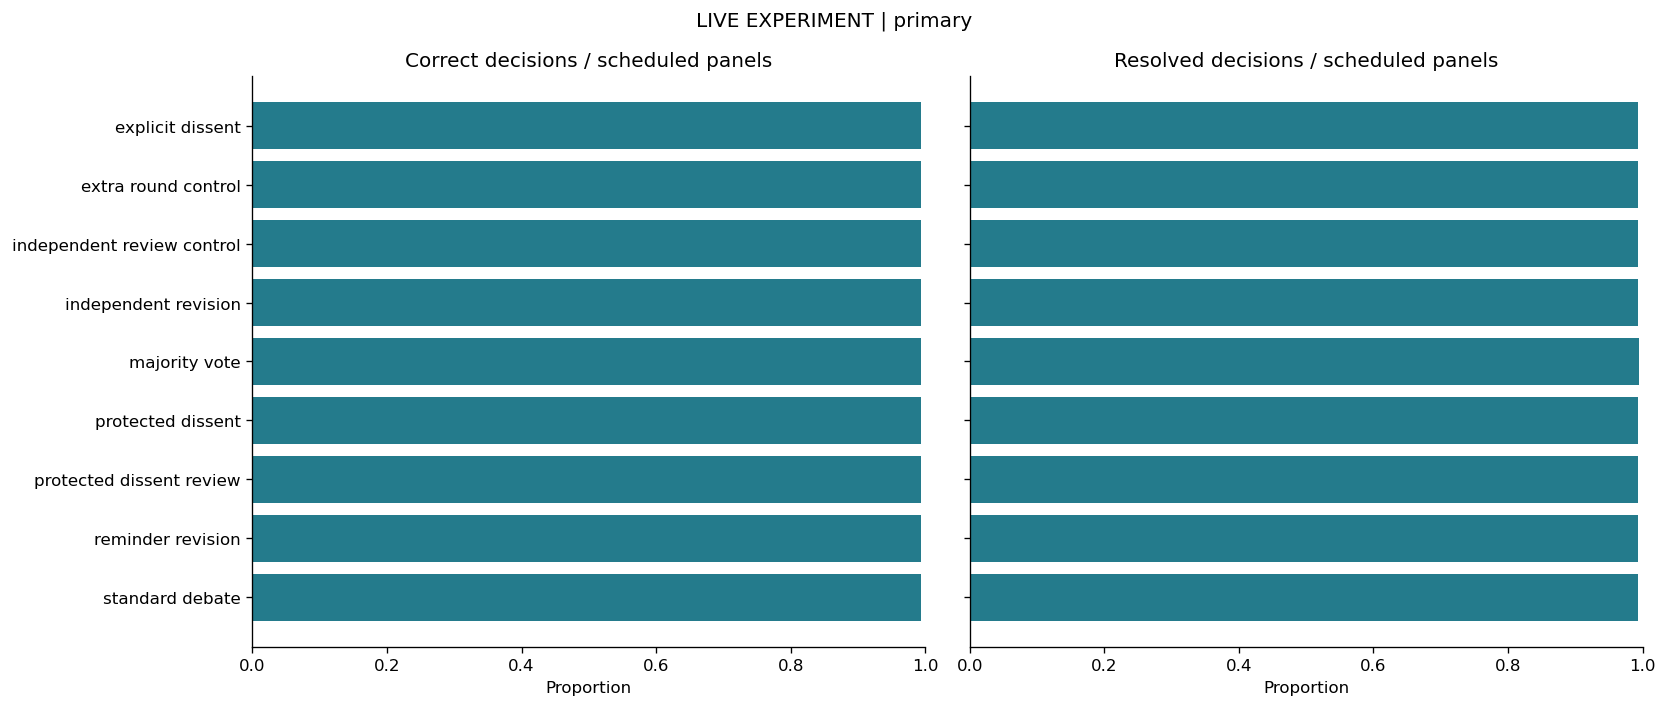

In [13]:
display(summary[['model_id','scope','protocol','available_panels','scheduled_panels','missing_panels','success_over_scheduled','accuracy_complete_cases','coverage_over_scheduled','accuracy_when_resolved']])
for model in summary.model_id.unique():
    table = summary[(summary.model_id == model) & (summary.scope == 'all')]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    labels = table.protocol.str.replace('_',' ')
    for ax, field, title in zip(axes, ['success_over_scheduled','coverage_over_scheduled'], ['Correct decisions / scheduled panels','Resolved decisions / scheduled panels']):
        ax.barh(labels, table[field], color='#247B8C')
        ax.set_xlim(0,1)
        ax.set_title(title)
        ax.set_xlabel('Proportion')
    axes[0].invert_yaxis()
    fig.suptitle(f'{BANNER} | {model}')
    fig.tight_layout()
    fig.savefig(FIGURES / f'{model}_accuracy_coverage.png', dpi=180, bbox_inches='tight')
    fig.savefig(FIGURES / f'{model}_accuracy_coverage.pdf', bbox_inches='tight')
    show(fig)
    plt.close(fig)

## Correct-minority outcomes

Recovery means a correct final decision on an initially majority-wrong/minority-correct panel. Suppression requires a unanimous wrong final panel agreeing with the wrong final decision. A wrong majority alone is not suppression. An independent appeal can repair the decision without repairing any panel member's answer. Empty focus strata are undefined, not zero.

,model_id,scope,protocol,focus_scheduled,focus_available,minority_recovery,minority_suppression,minority_agent_survival,false_dissent,false_qualifying_dissent,escalation_rate
0,primary,all,explicit_dissent,1,1,1.0,0.0,1.0,None,None,0.0
1,primary,all,extra_round_control,1,1,1.0,0.0,1.0,None,None,0.0
2,primary,all,independent_review_control,1,1,1.0,0.0,1.0,None,None,0.0
3,primary,all,independent_revision,1,1,1.0,0.0,1.0,None,None,0.0
4,primary,all,majority_vote,1,1,0.0,0.0,1.0,None,None,0.0
5,primary,all,protected_dissent,1,1,1.0,0.0,1.0,None,None,0.0
6,primary,all,protected_dissent_review,1,1,1.0,0.0,1.0,None,None,0.0
7,primary,all,reminder_revision,1,1,1.0,0.0,1.0,None,None,0.0
8,primary,all,standard_debate,1,1,1.0,0.0,1.0,None,None,0.0
9,primary,bbh,explicit_dissent,1,1,1.0,0.0,1.0,None,None,0.0


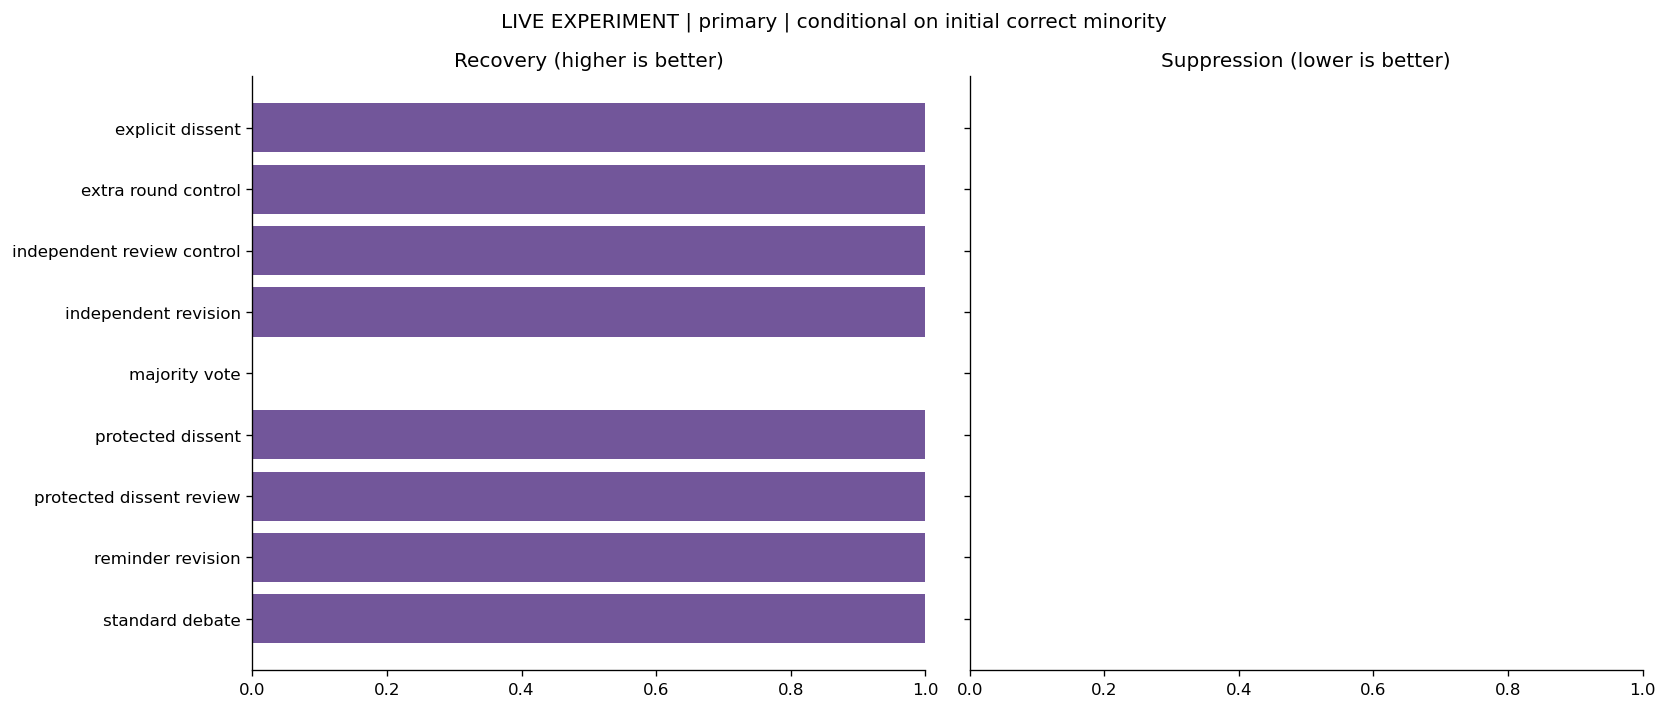

In [14]:
focus_table = summary[['model_id','scope','protocol','focus_scheduled','focus_available','minority_recovery','minority_suppression','minority_agent_survival','false_dissent','false_qualifying_dissent','escalation_rate']]
display(focus_table)
for model in summary.model_id.unique():
    table = summary[(summary.model_id == model) & (summary.scope == 'all')]
    fig, axes = plt.subplots(1,2,figsize=(14,6),sharey=True)
    for ax, field, title in zip(axes,['minority_recovery','minority_suppression'],['Recovery (higher is better)','Suppression (lower is better)']):
        values = pd.to_numeric(table[field], errors='coerce')
        ax.barh(table.protocol.str.replace('_',' '),values,color='#72569A')
        ax.set_xlim(0,1)
        ax.set_title(title)
        for i, value in enumerate(values):
            if pd.isna(value): ax.text(0.02,i,'N/A: empty focus stratum',va='center')
    axes[0].invert_yaxis()
    fig.suptitle(f'{BANNER} | {model} | conditional on initial correct minority')
    fig.tight_layout()
    fig.savefig(FIGURES / f'{model}_minority_outcomes.png',dpi=180,bbox_inches='tight')
    show(fig)
    plt.close(fig)

## Planned paired comparisons

Effects are treatment minus baseline. Positive values favor treatment for accuracy/recovery; negative values favor treatment for suppression. Percentile bootstrap intervals resample questions within source/family strata, carrying all repetitions of each question together. Exact McNemar tests apply when each question contributes once. Repeated panels use question-cluster sign flips, which assume paired exchangeability under the null.

Holm adjustment covers all planned endpoint/source-scope comparisons within each model. These intervals are marginal, not simultaneous. Cross-model significance claims need a broader correction plan. These observational protocol contrasts and small pilot samples warrant cautious interpretation; a low p-value alone does not isolate a social mechanism.

,model_id,scope,endpoint,treatment,baseline,n_questions,n_pairs,missing_pairs,difference,bootstrap_95,test,p_value,p_holm,bootstrap_degenerate
0,primary,all,accuracy,protected_dissent,standard_debate,600,1789,11,0.0,"[0.0, 0.0]",exact_question_cluster_sign_flip,1.0,1.0,True
1,primary,all,minority_recovery,protected_dissent,standard_debate,1,1,0,0.0,None,exact_mcnemar,1.0,1.0,False
2,primary,all,minority_suppression,protected_dissent,standard_debate,1,1,0,0.0,None,exact_mcnemar,1.0,1.0,False
3,primary,all,accuracy,protected_dissent_review,standard_debate,600,1789,11,0.0,"[0.0, 0.0]",exact_question_cluster_sign_flip,1.0,1.0,True
4,primary,all,minority_recovery,protected_dissent_review,standard_debate,1,1,0,0.0,None,exact_mcnemar,1.0,1.0,False
5,primary,all,minority_suppression,protected_dissent_review,standard_debate,1,1,0,0.0,None,exact_mcnemar,1.0,1.0,False
6,primary,all,accuracy,protected_dissent,explicit_dissent,600,1789,11,0.0,"[0.0, 0.0]",exact_question_cluster_sign_flip,1.0,1.0,True
7,primary,all,minority_recovery,protected_dissent,explicit_dissent,1,1,0,0.0,None,exact_mcnemar,1.0,1.0,False
8,primary,all,minority_suppression,protected_dissent,explicit_dissent,1,1,0,0.0,None,exact_mcnemar,1.0,1.0,False
9,primary,all,accuracy,protected_dissent,extra_round_control,600,1789,11,0.0,"[0.0, 0.0]",exact_question_cluster_sign_flip,1.0,1.0,True


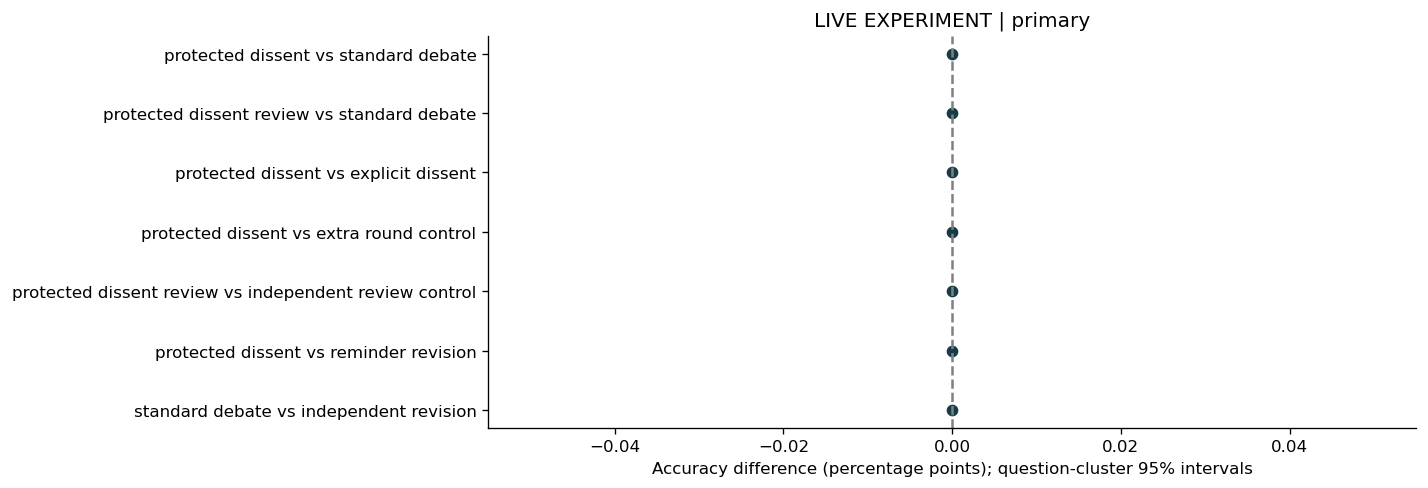

In [15]:
display(contrasts[['model_id','scope','endpoint','treatment','baseline','n_questions','n_pairs','missing_pairs','difference','bootstrap_95','test','p_value','p_holm','bootstrap_degenerate']])
for model in contrasts.model_id.unique():
    table = contrasts[(contrasts.model_id == model) & (contrasts.scope == 'all') & (contrasts.endpoint == 'accuracy')].copy()
    table = table[table.bootstrap_95.map(lambda value: isinstance(value,list))]
    if table.empty:
        print(f'{model}: not enough paired questions for intervals')
        continue
    fig, ax = plt.subplots(figsize=(12, max(4, len(table)*0.6)))
    for position, (_, row) in enumerate(table.iterrows()):
        low, high = row.bootstrap_95
        ax.plot([100*low,100*high],[position,position],color='#247B8C',linewidth=2)
        ax.plot(100*row.difference,position,'o',color='#163B45')
    ax.set_yticks(range(len(table)), [a.replace('_',' ')+' vs '+b.replace('_',' ') for a,b in zip(table.treatment,table.baseline)])
    ax.axvline(0,color='grey',linestyle='--')
    ax.set_xlabel('Accuracy difference (percentage points); question-cluster 95% intervals')
    ax.invert_yaxis()
    ax.set_title(f'{BANNER} | {model}')
    fig.tight_layout()
    fig.savefig(FIGURES / f'{model}_paired_effects.png',dpi=180,bbox_inches='tight')
    fig.savefig(FIGURES / f'{model}_paired_effects.pdf',bbox_inches='tight')
    show(fig)
    plt.close(fig)

## Agent transitions and resource trade-offs

Transition counts describe panel members; do not use agents as independent statistical samples. The two yoked controls match logical call counts to the protected branches on the same escalation events. They do not match prompt/output tokens. Physical costs count shared prefixes once, while standalone costs allocate each protocol its full path. Unknown retry charges remain missing; a reported-cost threshold is not a guaranteed dollar cap.

,model_id,protocol,correct_to_correct,correct_to_wrong,wrong_to_correct,wrong_to_wrong,mean_calls,mean_request_attempts,mean_tokens,mean_cost_usd,mean_latency_seconds
0,primary,explicit_dissent,8908,0,37,0,5.178871,5.184461,NaN,NaN,25.897424
1,primary,extra_round_control,8908,0,37,0,5.178871,5.184461,NaN,NaN,25.905489
2,primary,independent_review_control,8908,0,37,0,5.178871,5.184461,NaN,NaN,25.905489
3,primary,independent_revision,8908,0,30,7,5.089435,5.095025,NaN,NaN,25.593112
4,primary,majority_vote,8915,0,0,40,5.000000,5.005583,NaN,NaN,25.258346
5,primary,protected_dissent,8908,0,37,0,5.178871,5.184461,NaN,NaN,25.910526
6,primary,protected_dissent_review,8908,0,37,0,5.178871,5.184461,NaN,NaN,25.910526
7,primary,reminder_revision,8908,0,37,0,5.178871,5.184461,NaN,NaN,25.868510
8,primary,standard_debate,8908,0,37,0,5.089435,5.095025,NaN,NaN,25.609707


,calls,request_attempts,retries,latency_seconds_sum,prompt_tokens,prompt_tokens_known_subtotal,prompt_tokens_missing_calls,completion_tokens,completion_tokens_known_subtotal,completion_tokens_missing_calls,total_tokens,total_tokens_known_subtotal,total_tokens_missing_calls,cost,cost_known_subtotal,cost_missing_calls,model_id,seed,failed_calls,pending_calls
0,3446,3451,5,10949.725785,None,1457833,3,None,2188867,3,None,3646700,3,None,2.880986,3,primary,2027,1,0
1,3325,3328,3,21633.706196,None,1293857,3,None,2031574,3,None,3325431,3,None,2.640559,3,primary,2028,4,0
2,3199,3201,2,16198.556511,None,1182947,2,None,1927419,2,None,3110366,2,None,2.485168,2,primary,2029,6,0


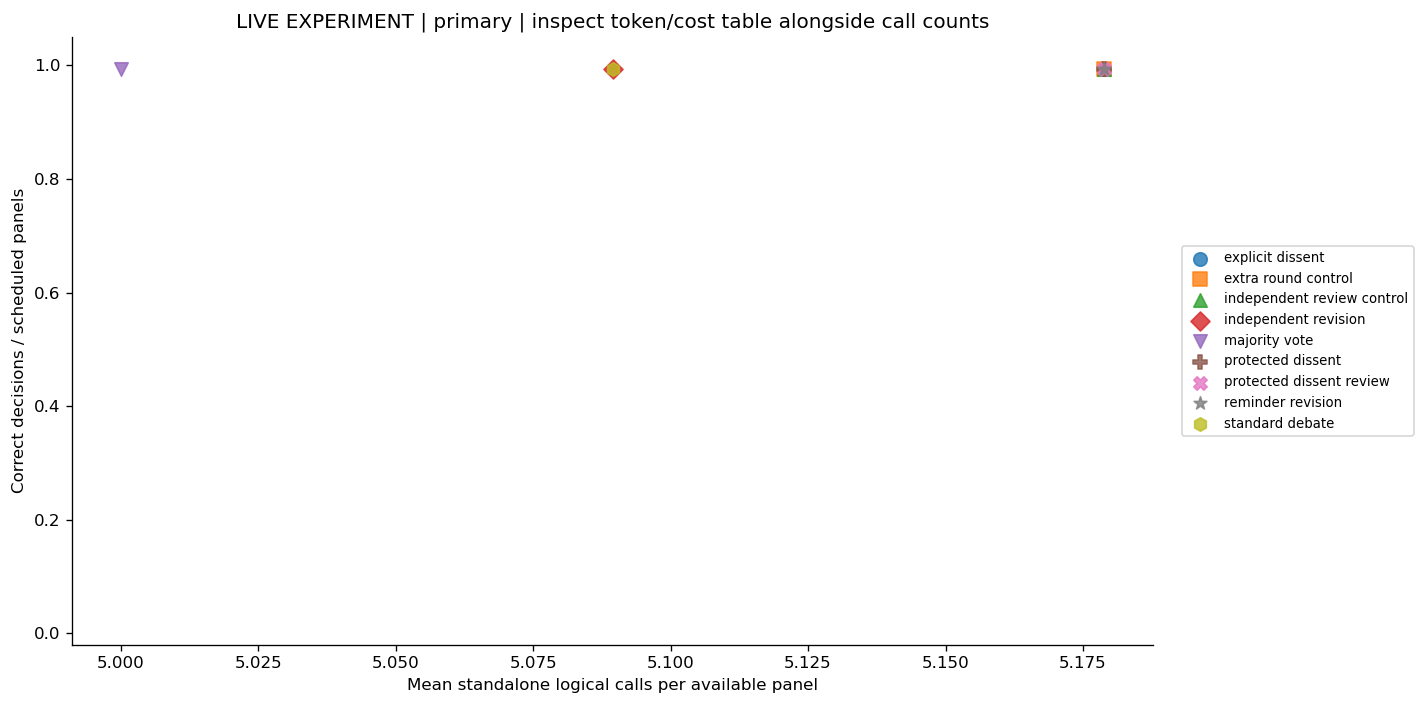

In [16]:
display(summary[summary.scope == 'all'][['model_id','protocol','correct_to_correct','correct_to_wrong','wrong_to_correct','wrong_to_wrong','mean_calls','mean_request_attempts','mean_tokens','mean_cost_usd','mean_latency_seconds']])
display(resources)
for model in summary.model_id.unique():
    table = summary[(summary.model_id == model) & (summary.scope == 'all')]
    fig, ax = plt.subplots(figsize=(12,6))
    markers = ['o','s','^','D','v','P','X','*','h']
    for i, (_, row) in enumerate(table.iterrows()):
        if pd.notna(row.mean_calls):
            ax.scatter(row.mean_calls,row.success_over_scheduled,s=65,marker=markers[i % len(markers)],label=row.protocol.replace('_',' '),alpha=0.8)
    ax.legend(loc='center left',bbox_to_anchor=(1.02,0.5),fontsize=8)
    ax.set_xlabel('Mean standalone logical calls per available panel')
    ax.set_ylabel('Correct decisions / scheduled panels')
    ax.set_ylim(-0.02,1.05)
    ax.set_title(f'{BANNER} | {model} | inspect token/cost table alongside call counts')
    fig.tight_layout()
    fig.savefig(FIGURES / f'{model}_cost_accuracy.png',dpi=180,bbox_inches='tight')
    show(fig)
    plt.close(fig)

## Audit sample and exports

This stratified sample is for qualitative inspection, not estimating population rates. Use its task IDs to inspect the saved initial responses, debate, dissent, and reviewer inputs. Inspect natural-language social cues in reviewer arguments: lexical filtering does not prove perfect blinding.

CSV exports contain derived analysis data, not credentials. Record any annotation corrections separately and rerun the analysis with disclosed changes.

In [17]:
audit_sample = (screen.sort_values(['model_id','dataset','task_id','seed']).groupby(['model_id','dataset','initial_category'], group_keys=False).head(2))
display(audit_sample[['model_id','dataset','seed','task_id','initial_category','initial_answers','correct_answer']])
summary.to_csv(EXPORTS / 'descriptive.csv',index=False)
contrasts.to_csv(EXPORTS / 'paired_comparisons.csv',index=False)
resources.to_csv(EXPORTS / 'resources.csv',index=False)
audit_sample.to_csv(EXPORTS / 'manual_audit_sample.csv',index=False)
rows.to_csv(EXPORTS / 'analysis_rows.csv',index=False)
print('Saved tables to',EXPORTS)
print('Saved figures to',FIGURES)
print('Statistical plan:',json.dumps(report['identity']['statistics'],indent=2))

,model_id,dataset,seed,task_id,initial_category,initial_answers,correct_answer
0,primary,bbh,2027,bbh::bbh/logical_deduction_five_objects/0004,unanimous_correct,"[D, D, D, D, D]",D
600,primary,bbh,2028,bbh::bbh/logical_deduction_five_objects/0004,unanimous_correct,"[D, D, D, D, D]",D
610,primary,bbh,2028,bbh::bbh/logical_deduction_five_objects/0029,majority_correct_minority_wrong,"[D, D, D, B, D]",D
55,primary,bbh,2027,bbh::bbh/logical_deduction_five_objects/0165,majority_correct_minority_wrong,"[E, D, D, D, E]",D
655,primary,bbh,2028,bbh::bbh/logical_deduction_five_objects/0165,majority_wrong_minority_correct,"[D, E, E, D, E]",D
301,primary,fresh,2027,fresh::boolean-0001,unanimous_correct,"[C, C, C, C, C]",C
901,primary,fresh,2028,fresh::boolean-0001,unanimous_correct,"[C, C, C, C, C]",C
304,primary,fresh,2027,fresh::boolean-0004,majority_correct_minority_wrong,"[A, C, C, C, C]",C
1510,primary,fresh,2029,fresh::boolean-0010,majority_correct_minority_wrong,"[A, A, A, A, B]",A
1561,primary,fresh,2029,fresh::boolean-0061,initial_unavailable,[],B


Saved tables to C:\Users\MingZeTang\Documents\GitHub\aamas27\runs\study-01\tables
Saved figures to C:\Users\MingZeTang\Documents\GitHub\aamas27\runs\study-01\figures
Statistical plan: {
  "bootstrap_samples": 2000,
  "seed": 2027,
  "comparisons": [
    [
      "protected_dissent",
      "standard_debate"
    ],
    [
      "protected_dissent_review",
      "standard_debate"
    ],
    [
      "protected_dissent",
      "explicit_dissent"
    ],
    [
      "protected_dissent",
      "extra_round_control"
    ],
    [
      "protected_dissent_review",
      "independent_review_control"
    ],
    [
      "protected_dissent",
      "reminder_revision"
    ],
    [
      "standard_debate",
      "independent_revision"
    ]
  ]
}


## Interpretation checklist

- Report unique questions, model/seed panels, missingness, coverage and focus-stratum size.
- Compare protected dissent with both ordinary debate and matched-call controls.
- Report outcomes on majority-correct teams as well as correct minorities; dissent may harm good decisions.
- Keep public and fresh results separate; do not claim public questions were unseen in training.
- Do not tune prompts or change sample selection after examining evaluation effects.
- A three-question preflight validates API behavior, not power, model calibration, or conference readiness.
- Treat empty strata, very small numbers of questions, and degenerate intervals as limitations.

Method references: [SciPy binomial-test documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html) and [paired bootstrap documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html). The repository implementation uses its own tested standard-library routines; the cluster and multiplicity choices are specified in `docs/research-workflow.md`.

## Inspect a saved response
Change `CALL_INDEX` and rerun this cell to inspect a different saved call. The structured response includes the returned answer and explanation, not hidden internal reasoning. The journal path contains the full request, returned API response, and attempt history. Failed calls may have no parsed response.

In [18]:
CALL_INDEX = 0
call_files = sorted((RUN_DIR / 'units').glob('*/calls/*.json'))
if not call_files:
    print('No call journals found.')
elif not 0 <= CALL_INDEX < len(call_files):
    print('Choose CALL_INDEX from 0 to', len(call_files) - 1)
else:
    path = call_files[CALL_INDEX]
    journal = json.loads(path.read_text(encoding='utf-8'))
    print('Journal:', path)
    print('Call:', journal.get('call_id'), '| Status:', journal.get('status'))
    print('Attempts:', len(journal.get('attempts', [])))
    print(json.dumps(journal.get('parsed', {'note': 'No valid structured response'}),
                     indent=2, ensure_ascii=False))

Journal: C:\Users\MingZeTang\Documents\GitHub\aamas27\runs\study-01\units\23e357cb32dd71fa\calls\0000e7f52576381c419b70fbaf7250b13b93812d6436b904508255086d1ad206.json
Call: fresh::ordering-0000/debate/0 | Status: ok
Attempts: 1
{
  "answer": "A",
  "confidence": 1,
  "reasoning": "The constraints imply A<E<D<F, C<D<F, and B must come after both A and C. Considering C's possible position before D: if C is before A, the relative order is C,A,E,D,F and B has 4 possible later positions; if C is between A and E, the order is A,C,E,D,F and B has 4 possible later positions; if C is between E and D, the order is A,E,C,D,F and B has 3 possible later positions. Total = 4+4+3 = 11, matching option A."
}


## Save and resume

Save this notebook with **Ctrl+S** to retain its displayed output. Raw calls and results are already saved under `RUN_DIR`; tables and figures are exported there too. `runs/` is ignored by Git: back it up separately with the frozen code, configuration and datasets, excluding `.env`.

For an interrupted preflight only, set `CONFIG = RUN_BASE / 'config.json'` and call:
```python
execute_study(CONFIG, RUN_DIR, 'independent', live=True, retry_failed=True)
execute_study(CONFIG, RUN_DIR, 'deliberate', live=True, retry_failed=True)
os.environ['DISSENT_STUDY_DIR'] = str(RUN_DIR)
```
Then rerun the result cells. This reuses its saved development questions. Do not regenerate them in the same directory. If you restart the kernel, run setup/settings first; do not execute the preflight collection cell again for an interrupted run.

For a partial study after interrupting deliberation, you may run the analysis cells with `DISSENT_STUDY_DIR` set to that run. Interpret their missing-result denominators; partial results are not the final study.